In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/datasets/ESC-50-master.zip"
extract_path = "/content/ESC-50"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [3]:
import os
os.listdir("/content/ESC-50/ESC-50-master")


['esc50.gif',
 'requirements.txt',
 'pytest.ini',
 'README.md',
 '.gitignore',
 'audio',
 '.github',
 'tests',
 '.circleci',
 'LICENSE',
 'meta']

In [4]:
os.listdir("/content/ESC-50/ESC-50-master/audio")[:10]


['3-124958-A-28.wav',
 '5-211197-A-24.wav',
 '1-80840-A-13.wav',
 '5-234855-A-25.wav',
 '4-167642-A-21.wav',
 '5-179866-A-43.wav',
 '2-173618-A-39.wav',
 '3-110913-C-7.wav',
 '3-51909-B-42.wav',
 '5-257839-A-14.wav']

In [5]:
import pandas as pd

csv_path = "/content/ESC-50/ESC-50-master/meta/esc50.csv"
df = pd.read_csv(csv_path)

df.head()


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [6]:
sorted(df['category'].unique())


['airplane',
 'breathing',
 'brushing_teeth',
 'can_opening',
 'car_horn',
 'cat',
 'chainsaw',
 'chirping_birds',
 'church_bells',
 'clapping',
 'clock_alarm',
 'clock_tick',
 'coughing',
 'cow',
 'crackling_fire',
 'crickets',
 'crow',
 'crying_baby',
 'dog',
 'door_wood_creaks',
 'door_wood_knock',
 'drinking_sipping',
 'engine',
 'fireworks',
 'footsteps',
 'frog',
 'glass_breaking',
 'hand_saw',
 'helicopter',
 'hen',
 'insects',
 'keyboard_typing',
 'laughing',
 'mouse_click',
 'pig',
 'pouring_water',
 'rain',
 'rooster',
 'sea_waves',
 'sheep',
 'siren',
 'sneezing',
 'snoring',
 'thunderstorm',
 'toilet_flush',
 'train',
 'vacuum_cleaner',
 'washing_machine',
 'water_drops',
 'wind']

In [7]:
animal_classes = [
    "dog", "cat", "cow", "sheep", "frog",
    "hen", "rooster", "pig", "chirping_birds",
    "crow", "insects", "crickets"
]

df_animals = df[df['category'].isin(animal_classes)]
df_animals.reset_index(drop=True, inplace=True)

print(df_animals.head())
print("Total samples:", len(df_animals))


            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2   1-103298-A-9.wav     1       9            crow  False    103298    A
3   1-110389-A-0.wav     1       0             dog   True    110389    A
4   1-121951-A-8.wav     1       8           sheep  False    121951    A
Total samples: 480


In [8]:
!pip install tensorflow tensorflow_hub librosa


In [9]:
import tensorflow_hub as hub

yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")


In [10]:
import librosa
import numpy as np

def load_audio(file_path, sr=16000):
    # Load audio file at 16kHz, mono
    waveform, _ = librosa.load(file_path, sr=sr, mono=True)
    return waveform


In [11]:
X = []
y = []

audio_dir = "/content/ESC-50/ESC-50-master/audio/"

for i, row in df_animals.iterrows():
    file_path = audio_dir + row['filename']
    waveform = load_audio(file_path)

    # YAMNet returns scores, embeddings, spectrogram
    scores, embeddings, spectrogram = yamnet_model(waveform)

    # Take mean across time axis to get fixed-size vector (1024)
    embedding_vector = np.mean(embeddings.numpy(), axis=0)

    X.append(embedding_vector)
    y.append(row['category'])

X = np.array(X)
y = np.array(y)

print("Embeddings shape:", X.shape)
print("Labels shape:", y.shape)


Embeddings shape: (480, 1024)
Labels shape: (480,)


In [12]:
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save encoder for later local inference
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,       # 20% for testing
    random_state=42,
    stratify=y_encoded   # Keeps class balance
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 384
Testing samples: 96


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

num_classes = len(np.unique(y_encoded))  # Should be 12

model = Sequential([
    Dense(512, activation='relu', input_shape=(1024,)),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         6,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,956 (2.03 MB)

 Trainable params: 530,956 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,          # Enough for convergence
    batch_size=32,
    verbose=1
)


Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3850 - loss: 2.3518 - val_accuracy: 0.8542 - val_loss: 1.1178
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8084 - loss: 1.0289 - val_accuracy: 0.8229 - val_loss: 0.7303
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8801 - loss: 0.5122 - val_accuracy: 0.8750 - val_loss: 0.5435
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8554 - loss: 0.6161 - val_accuracy: 0.8542 - val_loss: 0.5213
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8872 - loss: 0.4650 - val_accuracy: 0.8854 - val_loss: 0.4074
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9005 - loss: 0.3842 - val_accuracy: 0.8646 - val_loss: 0.4150
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9150 - loss: 0.3983 - val_accuracy: 0.8958 - val_loss: 0.3961
Epoch 8/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8907 - loss: 0.3871 - val_accuracy: 0.8958 - val

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8997 - loss: 0.4109
Test Accuracy: 0.9166666865348816


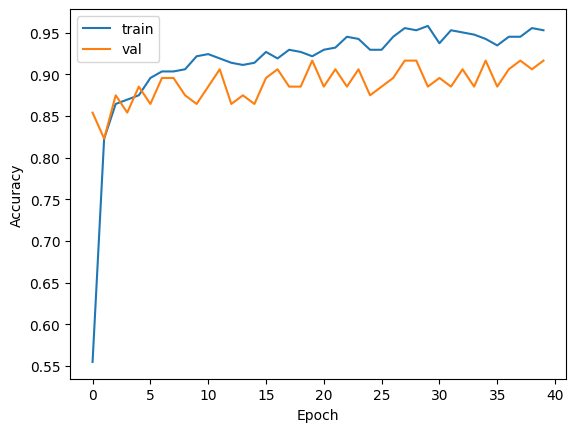

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [19]:
model.save("animal_species_classifier.h5")


In [20]:
import shutil
shutil.move("animal_species_classifier.h5", "/content/drive/MyDrive/")
shutil.move("label_encoder.pkl", "/content/drive/MyDrive/")


'/content/drive/MyDrive/label_encoder.pkl'

In [21]:
# Save classifier
model.save("animal_species_classifier.h5")

# Save label encoder (already done)
# with open("label_encoder.pkl", "wb") as f:
#     pickle.dump(le, f)


In [22]:
import shutil
shutil.move("animal_species_classifier.h5", "/content/drive/MyDrive/")
shutil.move("label_encoder.pkl", "/content/drive/MyDrive/")


Error: Destination path '/content/drive/MyDrive/animal_species_classifier.h5' already exists

In [24]:
import os
import shutil

# Path to original audio folder
audio_dir = "/content/ESC-50/ESC-50-master/audio/"

# Create new folder for filtered animal audio
animal_audio_dir = "/content/animal_audio"
os.makedirs(animal_audio_dir, exist_ok=True)


In [25]:
for filename in df_animals['filename']:
    src_path = os.path.join(audio_dir, filename)
    dst_path = os.path.join(animal_audio_dir, filename)
    shutil.copy(src_path, dst_path)

print("All filtered animal audio files copied!")


All filtered animal audio files copied!


In [26]:
shutil.make_archive("/content/animal_audio", 'zip', "/content/animal_audio")
print("Zipped dataset ready for download: animal_audio.zip")


Zipped dataset ready for download: animal_audio.zip


In [27]:
shutil.make_archive("/content/animal_audio", 'zip', "/content/animal_audio")
print("Zipped dataset ready for download: animal_audio.zip")


Zipped dataset ready for download: animal_audio.zip


In [28]:
from google.colab import files

files.download("/content/animal_audio.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-2897896641.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_animals, x='category', palette='viridis')


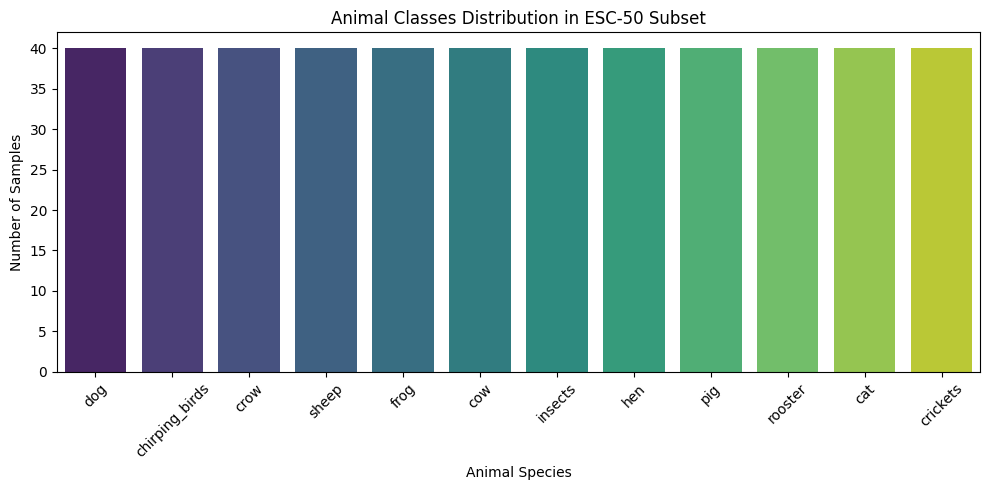

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df_animals, x='category', palette='viridis')
plt.xticks(rotation=45)
plt.title("Animal Classes Distribution in ESC-50 Subset")
plt.ylabel("Number of Samples")
plt.xlabel("Animal Species")
plt.tight_layout()
plt.show()


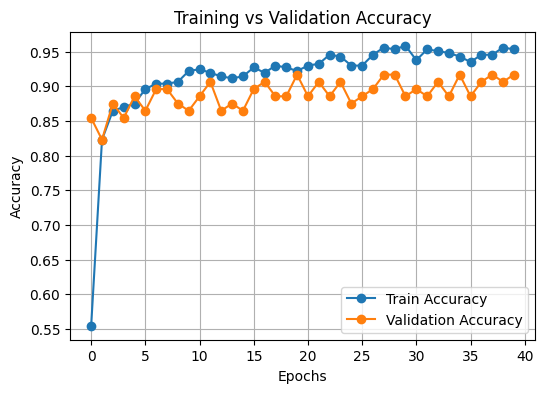

In [30]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


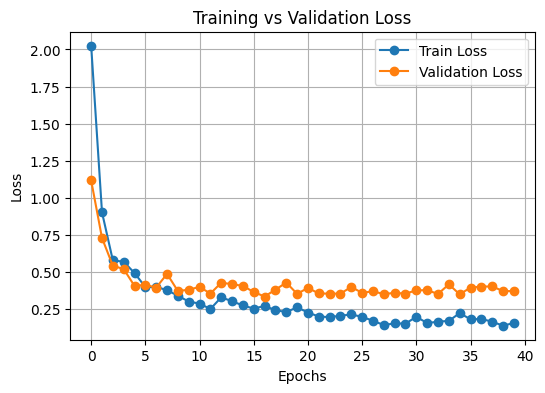

In [31]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(classifier.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.viridis, xticks_rotation=45)
plt.title("Confusion Matrix for Animal Species Classification")
plt.show()


NameError: name 'classifier' is not defined

In [33]:
import tensorflow as tf
import pickle

# Load trained classifier
classifier = tf.keras.models.load_model("models/animal_species_classifier.h5")

# Load label encoder
with open("models/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'models/animal_species_classifier.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [34]:
pred_probs = np.max(classifier.predict(X_test), axis=1)
plt.hist(pred_probs, bins=10, color='teal', alpha=0.7)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Samples")
plt.show()


NameError: name 'classifier' is not defined

In [39]:
import tensorflow as tf
import pickle

# Load trained classifier
classifier = tf.keras.models.load_model("models/Copy of animal_species_classifier.h5")

# Load label encoder
with open("models/Copy of label_encoder.pkl", "rb") as f:
    le = pickle.load(f)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'models/Copy of animal_species_classifier.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [40]:
import tensorflow as tf
import pickle

# Load trained classifier
classifier = tf.keras.models.load_model("datasets/animal_species_classifier.h5")

# Load label encoder
with open("datasets/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'datasets/animal_species_classifier.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)